# Project 9 — Netflix/Movies Data Analysis
## 🔥 Level 7 — Pandas + NumPy + Visualization

Find a movie/TV dataset and answer questions such as:

Which genres are most common?

Which year had the most releases?

Which countries produce the most content?

How has content production changed over time?

What is the average movie duration?

Which directors have produced the most titles?

What are the most common ratings?

Then create visualizations:

Chart 1

Content by year

Chart 2

Top 10 genres

Chart 3

Content by country

Chart 4

Rating distribution

Chart 5

Movie duration distribution

Chart 6

Movies vs TV shows

Use:

Pandas
NumPy
Matplotlib
Seaborn

Don't just make graphs.

Write conclusions for every graph.

For example:

"Content production increased significantly after 2015, with the largest growth occurring between 2018 and 2021."

That's what turns visualization into analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
df=pd.read_csv('D:/Code PlayGround/AI_ML_Prac/Netflix_Movies_Data_Analysis/netflix_titles.csv')
# print(df.head())
print(list(df.columns))
#show data beautifully using data wrangler
# print(df.info())

# print(df.head().to_string())

#show rows and columns
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
Rows: 8807, Columns: 12


Most Common Genres:
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


C:\Users\legion\AppData\Local\Temp\ipykernel_22712\3557216313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_common_genres.values, y=most_common_genres.index, palette="viridis")


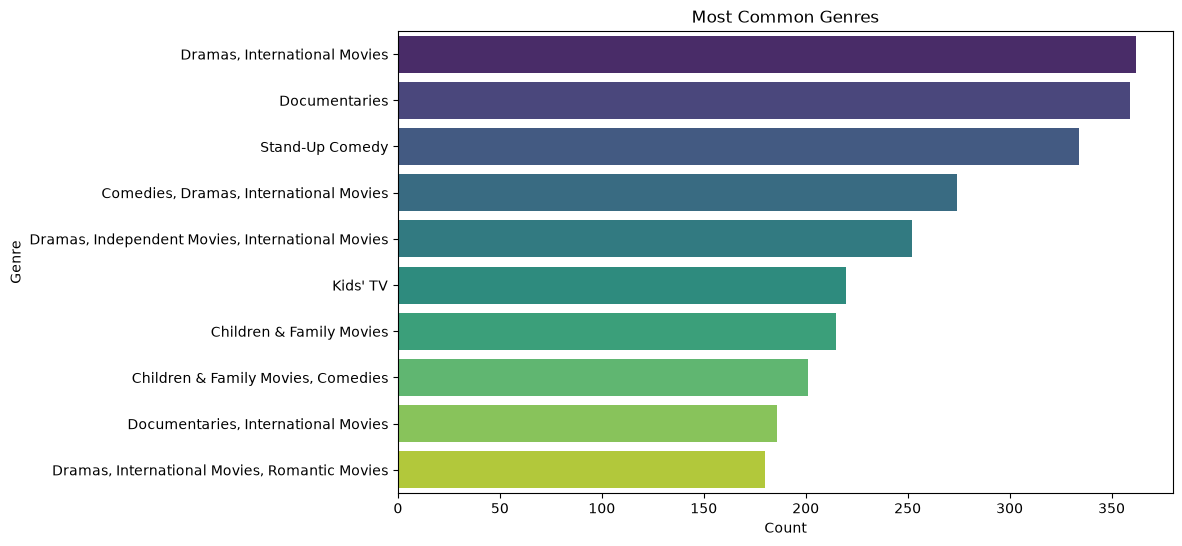

In [3]:
most_common_genres = df['listed_in'].value_counts().head(10)
print(f"Most Common Genres:\n{most_common_genres}")

# Create a bar plot of the most common genres
plt.figure(figsize=(10, 6))
sns.barplot(x=most_common_genres.values, y=most_common_genres.index, palette="viridis")
plt.title("Most Common Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [10]:
year_most_released = df['release_year'].value_counts().head(10)
print(f"Years with Most Releases:\n{year_most_released}")
fig = px.bar(x=year_most_released.index,
             y=year_most_released.values,
             title='Top 10 Years with Most Releases')
fig.update_traces(textposition='inside')
fig.show()

recent_years = df[df['release_year'] >= 2015]
print(f"Recent Years (2015 and later):\n{recent_years['release_year'].value_counts().sort_index()}")
# plt.figure(figsize=(10, 6))
# sns.barplot(x=year_most_released.index, y=year_most_released.values)
# plt.xlabel('Year')
# plt.ylabel('Number of Releases')
# plt.title('Top 10 Years with Most Releases')
# plt.show()

Years with Most Releases:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


Recent Years (2015 and later):
release_year
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


In [13]:
Country_produce_most_content = df['country'].value_counts().head(10)
print(f"Countries Producing Most Content:\n{Country_produce_most_content}")
fig=px.bar(x=Country_produce_most_content.index,
             y=Country_produce_most_content.values,
             title='Top 10 Countries Producing Most Content')
fig.update_traces(textposition='inside')
fig.show()

Countries Producing Most Content:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [17]:
content_production_changed_over_time = df.groupby('release_year')['type'].value_counts().unstack().fillna(0)
print(f"Content Production Changes Over Time:\n{content_production_changed_over_time}")
fig=px.line(content_production_changed_over_time, x=content_production_changed_over_time.index, y=['Movie', 'TV Show'],
                title='Content Production Changes Over Time')
fig.update_traces(mode='lines+markers')
fig.show()

Content Production Changes Over Time:
type          Movie  TV Show
release_year                
1925            0.0      1.0
1942            2.0      0.0
1943            3.0      0.0
1944            3.0      0.0
1945            3.0      1.0
...             ...      ...
2017          767.0    265.0
2018          767.0    380.0
2019          633.0    397.0
2020          517.0    436.0
2021          277.0    315.0

[74 rows x 2 columns]


In [18]:
average_movie_duration = df[df['type'] == 'Movie']['duration'].str.replace(' min', '').astype(float).mean()
print(f"Average Movie Duration: {average_movie_duration:.2f} minutes")
fig=px.histogram(df[df['type'] == 'Movie'], x=df[df['type'] == 'Movie']['duration'].str.replace(' min', '').astype(float),
                 nbins=30, title='Distribution of Movie Durations')
fig.update_layout(xaxis_title='Duration (minutes)', yaxis_title='Count')
fig.show()

Average Movie Duration: 99.58 minutes


In [20]:
directors_with_most_titles = df['director'].value_counts().head(20)
print(f"Directors with Most Titles:\n{directors_with_most_titles}")
fig=px.bar(x=directors_with_most_titles.index,
             y=directors_with_most_titles.values,
             title='Directors with Most Titles')
fig.update_traces(textposition='inside')
fig.show()

Directors with Most Titles:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Robert Rodriguez           8
Kunle Afolayan             8
Yılmaz Erdoğan             8
Fernando Ayllón            8
Ryan Polito                8
Troy Miller                8
Johnnie To                 8
Shannon Hartman            8
Name: count, dtype: int64


In [21]:
most_common_ratings = df['rating'].value_counts().head(10)
print(f"Most Common Ratings:\n{most_common_ratings}")
fig=px.bar(x=most_common_ratings.index,
             y=most_common_ratings.values,
             title='Most Common Ratings')
fig.update_traces(textposition='inside')
fig.show()

Most Common Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64
